# Clustering

In [98]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Data pre-processing

In [70]:
df = pd.read_parquet("history.parquet")

# Remove all rows for Mogadishu
df = df[df['capital'] != 'Mogadishu']

# Add season column based on month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

def get_decade(year):
    if 1995 <= year <= 2004:
        return '1995-2004'
    elif 2005 <= year <= 2014:
        return '2005-2014'
    elif 2015 <= year <= 2024:
        return '2015-2024'
    else:
        return 'Unknown'


df['date'] = pd.to_datetime(df['date'])

df['season'] = df['date'].dt.month.apply(get_season)
df['temp_variation'] = df['temp_max_c'] - df['temp_min_c']
df['year'] = df['date'].dt.year
df['decade'] = df['year'].apply(get_decade)

#We'll need it later
capital_to_country = df[['capital', 'country']].drop_duplicates().set_index('capital')['country'].to_dict()
#Columns to drop

columns_to_keep = ['temp_mean_c_approx', 'rain_mm', 'snow_mm', 'windspeed_10m_max_kmh', 'temp_variation', 'sunshine_duration_s', 'daylight_duration_s', 'capital', 'year', 'season', 'date', 'decade']
df = df[columns_to_keep]

In [71]:
# Aggregazioni globali

aggregation_per_capital = df.groupby(['capital']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

aggregation_per_year = df.groupby(['capital','year']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

aggregation_per_season = df.groupby(['capital','season']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

In [72]:
# Aggregazioni per decennio

# AGGREGATION PER CAPITAL AND DECADE
aggregation_per_capital_decade = df.groupby(['capital', 'decade']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

# AGGREGATION PER CAPITAL, DECADE AND SEASON
aggregation_per_capital_decade_season = df.groupby(['capital', 'decade', 'season']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

# Clustering globale per capitale

In [73]:
df_clusters = aggregation_per_capital
df_clusters.head(5)

,capital,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine
0,Abuja,26.823444,2.200733,38576.9,4551,0.00,0,43653.205642,33435.919106
1,Accra,26.848335,1.460698,20232.3,3841,0.00,0,43638.082460,36090.631905
2,Addis Ababa,15.732666,1.372649,50712.2,4856,0.00,0,43653.205642,37502.042483
3,Algiers,18.433478,5.715757,18498.8,2412,15.82,6,43878.875057,36932.462103
4,Alofi,25.278135,1.320144,54899.8,5162,0.00,0,43578.573185,35245.005225


In [74]:
# Scaling
features = ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_daylight', 'mean_sunshine']
X = df_clusters[features].copy()

#Log transform per asimmetria - consigliato ma da capire
#X["rain_total"] = np.log1p(X["rain_total"])
#X["snow_total"] = np.log1p(X["snow_total"])

#X.head(5)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [155]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA components to dataframe
df_clusters['pca1'] = X_pca[:, 0]
df_clusters['pca2'] = X_pca[:, 1]

# Print explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance ratio: [0.60246428 0.24939356]
Total variance explained: 85.19%


## K-Means

In [156]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
inertia = []

K_range = range(2, 9)

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    inertia.append(km.inertia_)

print(f"Silhouette scores: {sil_scores}")
print(f"Inertia scores: {inertia}")

Silhouette scores: [np.float64(0.4597704272425919), np.float64(0.36001881336758895), np.float64(0.3652049292123637), np.float64(0.375835369131384), np.float64(0.37411609925389094), np.float64(0.3611787682025164), np.float64(0.3345491910982947)]
Inertia scores: [709.6410269559767, 496.42172401873694, 381.50239333893103, 295.81835390855395, 259.6777114708004, 231.03776683430507, 212.02457058363257]


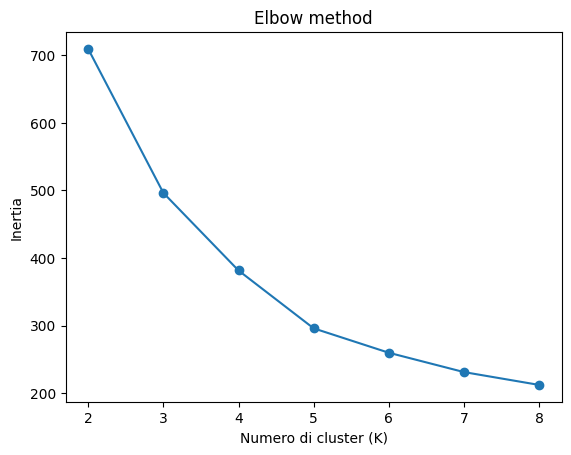

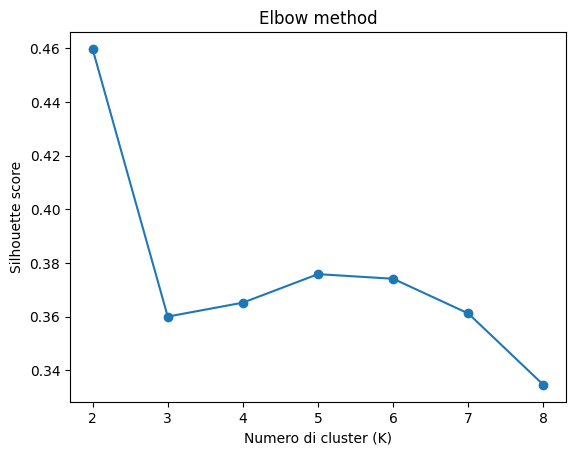

In [157]:
def plot_inertia(inertia_vec, k_range):
    plt.figure()
    plt.plot(k_range, inertia_vec, marker='o')
    plt.xlabel("Numero di cluster (K)")
    plt.ylabel("Inertia")
    plt.title("Elbow method")
    plt.show()

def plot_silhouette(silhouette_vec, k_range):
    plt.figure()
    plt.plot(k_range, silhouette_vec, marker='o')
    plt.xlabel("Numero di cluster (K)")
    plt.ylabel("Silhouette score")
    plt.title("Elbow method")
    plt.show()

plot_inertia(inertia, K_range)
plot_silhouette(sil_scores, K_range)


In [158]:
# Top cluster
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)

df_clusters["cluster"] = kmeans.fit_predict(X_scaled)

In [159]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

cluster_summary = (
    pd.DataFrame(centroids, columns=features)
    .assign(cluster=range(k))
)

cluster_summary

,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,cluster
0,21.712407,4.725469,16277.838889,2138.962963,29.883519,8.351852,43726.122392,37051.992572,0
1,6.393940,8.433678,21611.630769,3381.923077,4175.505385,1070.615385,44446.745923,25451.213740,1
2,24.588988,1.439451,57145.263492,6268.190476,32.451111,8.111111,43648.159301,35181.511200,2
3,10.937281,8.626440,20414.621212,2951.909091,1445.196667,358.393939,44044.739563,30405.560288,3


In [160]:
df_clusters['country'] = df_clusters['capital'].map(capital_to_country)
df_clusters.head(5)

,capital,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,cluster,country,pca1,pca2
0,Abuja,26.823444,2.200733,38576.9,4551,0.00,0,43653.205642,33435.919106,2,Nigeria,-1.353323,0.186800
1,Accra,26.848335,1.460698,20232.3,3841,0.00,0,43638.082460,36090.631905,0,Ghana,-1.455092,-0.616650
2,Addis Ababa,15.732666,1.372649,50712.2,4856,0.00,0,43653.205642,37502.042483,2,Ethiopia,-1.280265,0.348828
3,Algiers,18.433478,5.715757,18498.8,2412,15.82,6,43878.875057,36932.462103,0,Algeria,-0.063195,-1.246362
4,Alofi,25.278135,1.320144,54899.8,5162,0.00,0,43578.573185,35245.005225,2,Niue,-1.805503,0.616555


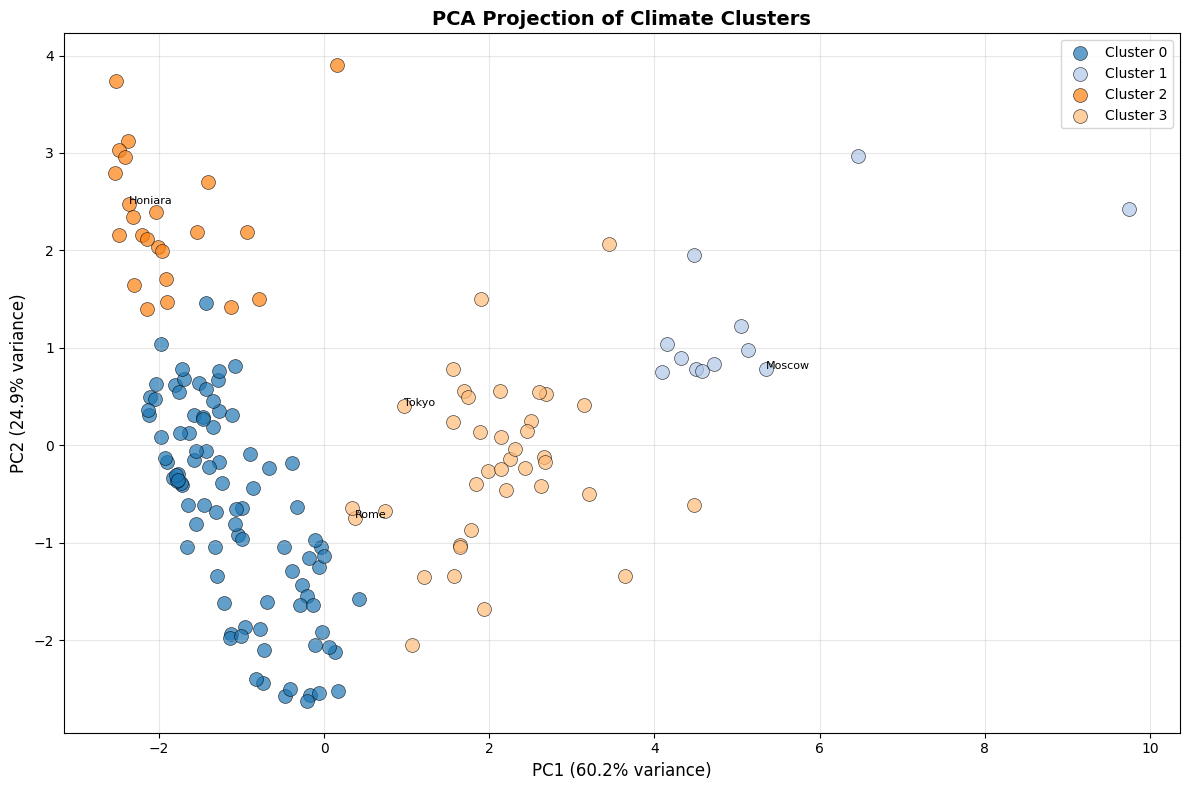

In [180]:
def plot_PCA(df_cluster_assignment, capitals = ['Rome', 'Honiara', 'Tokyo', 'Moscow']):
    # Plot PCA projection with cluster colors
    plt.figure(figsize=(12, 8))

    # Use tab10 colormap
    cmap = matplotlib.colormaps.get_cmap('tab20')
    colors = [cmap(i) for i in range(k)]

    # Plot each cluster
    for cluster_id in range(k):
        cluster_data = df_cluster_assignment[df_cluster_assignment['cluster'] == cluster_id]
        plt.scatter(
            cluster_data['pca1'], 
            cluster_data['pca2'],
            c=[colors[cluster_id]],
            label=f'Cluster {cluster_id}',
            alpha=0.7,
            s=100,
            edgecolors='black',
            linewidth=0.5
        )

    # Add labels for some capitals
    for capital in capitals:
        row = df_cluster_assignment[df_cluster_assignment["capital"] == capital]
        if not row.empty:
            plt.annotate(
                capital, 
                (row['pca1'].values[0], row['pca2'].values[0]),
                fontsize=8,
                alpha=1
            )

    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    plt.title('PCA Projection of Climate Clusters', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_PCA(df_clusters)

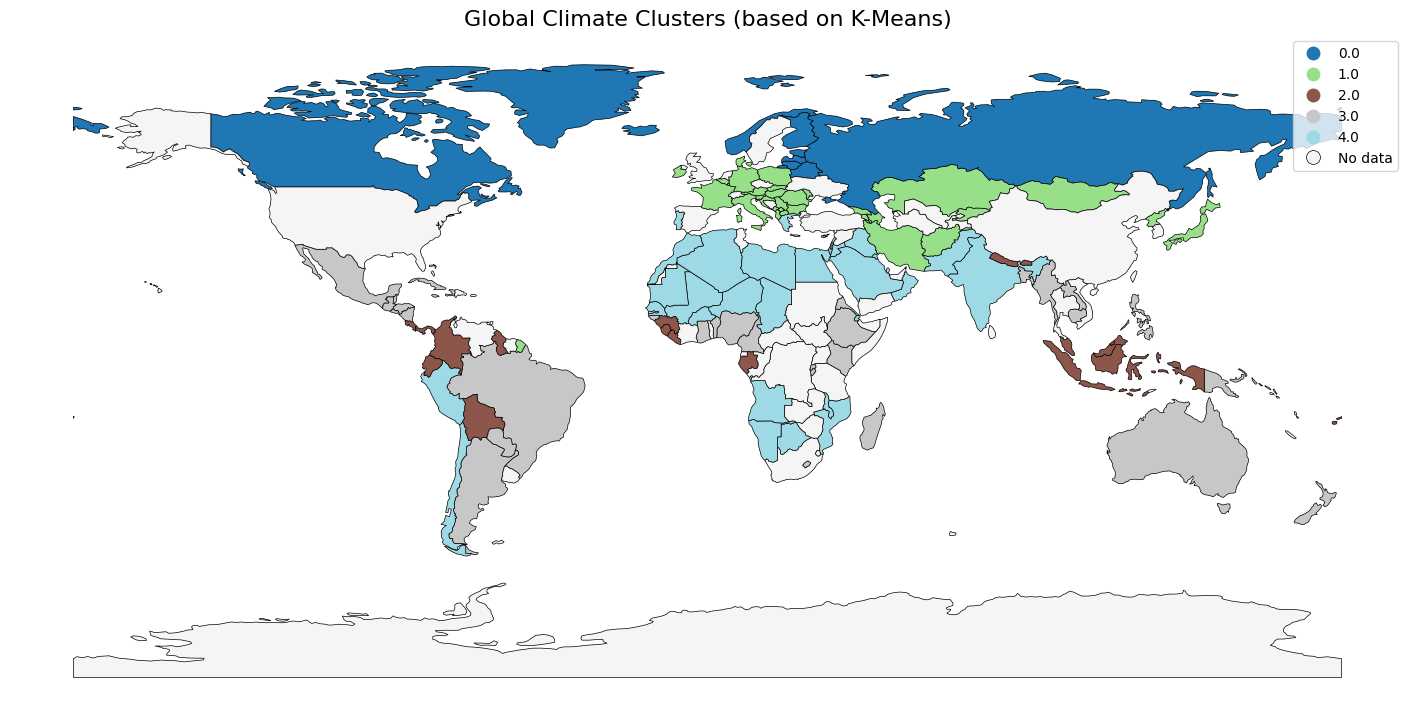

In [189]:
import geopandas as gpd

def plot_world(df_cluster_assignment, method=""):
    # World map data
    world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(world_url)

    # Merge temperature change data
    world_clusters = world.merge(
        df_cluster_assignment,
        how="left",
        left_on="NAME",
        right_on="country"
    )

    fig, ax = plt.subplots(1, 1, figsize=(18, 9))

    world_clusters.plot(
        column="cluster",
        categorical=True,
        cmap="tab20",          # colori discreti
        linewidth=0.5,
        edgecolor="black",
        legend=True,
        ax=ax,
        missing_kwds={
            "color": "whitesmoke",
            "label": "No data"
        }
    )

    ax.set_title(
        f"Global Climate Clusters (based on {method})",
        fontsize=16
    )

    ax.axis("off")
    plt.show()

plot_world(df_clusters, "K-Means")

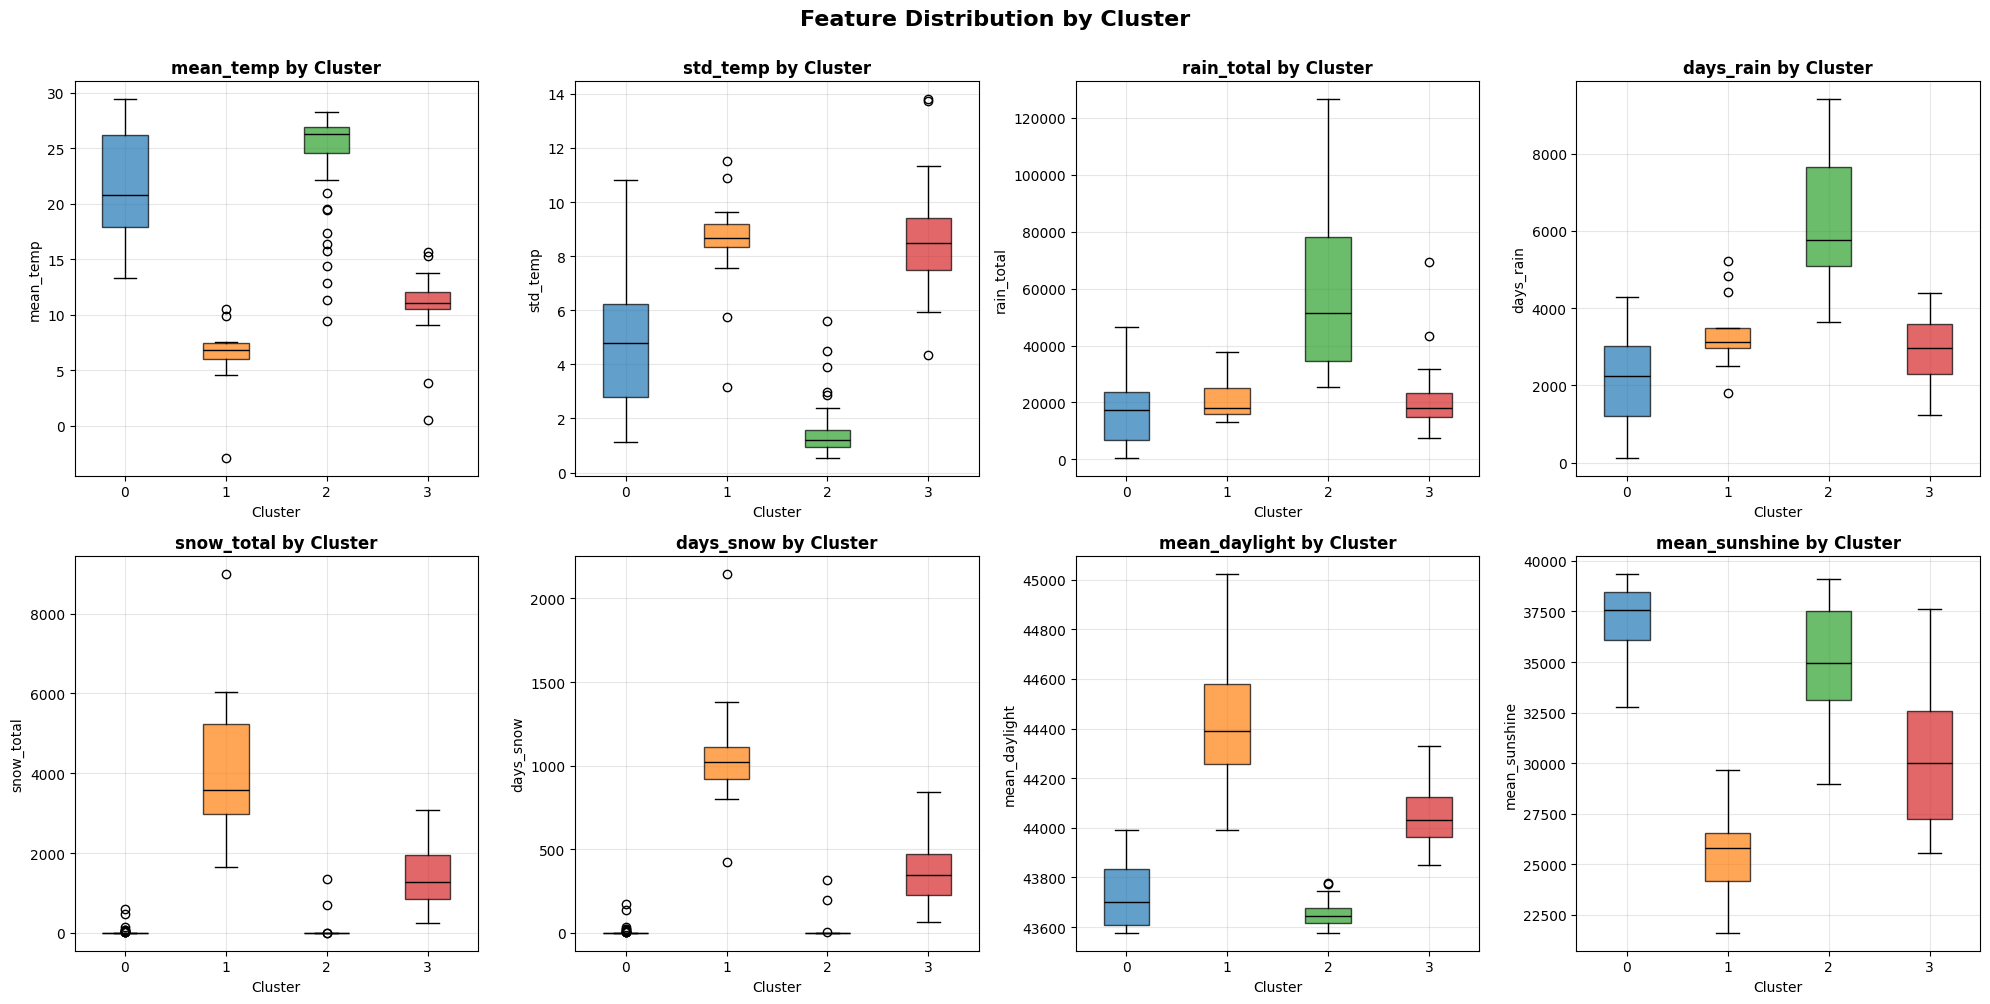

In [174]:
def plot_boxplots(df_cluster_assignment, n_clusters):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    # Use tab10 colormap (same as the map)
    cmap = matplotlib.colormaps.get_cmap('tab10')
    cluster_colors = {i: cmap(i) for i in range(n_clusters)}

    for i, feature in enumerate(features):
        ax = axes[i]
        
        # Create boxplot with colors
        box_data = [df_cluster_assignment[df_cluster_assignment['cluster'] == c][feature].values for c in range(n_clusters)]
        bp = ax.boxplot(box_data, tick_labels=range(n_clusters), patch_artist=True, 
                        medianprops={'color': 'black'}, boxprops={'alpha': 0.7, 'edgecolor': 'black'})
        
        # Apply colors to boxes
        for patch, cluster_id in zip(bp['boxes'], range(n_clusters)):
            patch.set_facecolor(cluster_colors[cluster_id])
        

        # Style the plot
        ax.set_title(f'{feature} by Cluster', fontsize=12, fontweight='bold')
        ax.set_xlabel('Cluster', fontsize=10)
        ax.set_ylabel(feature, fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Feature Distribution by Cluster', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

plot_boxplots(df_clusters, k)

# DBSCAN

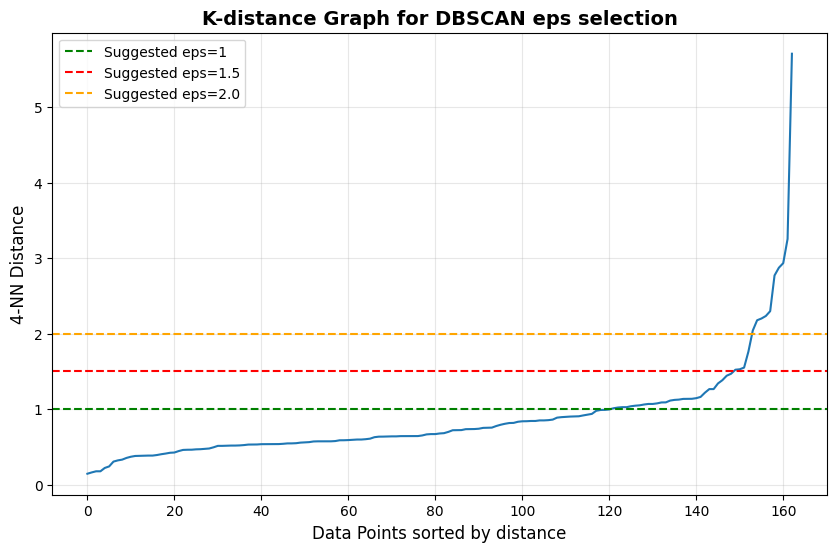

In [125]:
from sklearn.neighbors import NearestNeighbors

""" clustering = DBSCAN(eps=3, min_samples=2).fit(X_scaled)
df_clusters["cluster"] = clustering.labels_ """

# Calculate k-nearest neighbors distances
min_samples = 5
k_nn = min_samples - 1

neighbors = NearestNeighbors(n_neighbors=k_nn)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, k-1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Data Points sorted by distance', fontsize=12)
plt.ylabel(f'{k_nn}-NN Distance', fontsize=12)
plt.title('K-distance Graph for DBSCAN eps selection', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='g', linestyle='--', label='Suggested eps=1')
plt.axhline(y=1.5, color='r', linestyle='--', label='Suggested eps=1.5')
plt.axhline(y=2.0, color='orange', linestyle='--', label='Suggested eps=2.0')
plt.legend()
plt.show()

#eps = 1.25

In [127]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Test different eps and min_samples combinations
results = []

epss = [0.5, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0]
min_samples_list = [3, 4, 5, 6]

for eps in epss:
    for min_samples in min_samples_list:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Calculate silhouette only if we have valid clusters
        if n_clusters > 1 and n_noise < len(labels) - 1:
            sil_score = silhouette_score(X_scaled, labels)
        else:
            sil_score = -1
        
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil_score
        })
# Show results
results_df = pd.DataFrame(results)
print(results_df.sort_values('silhouette', ascending=False).head(10))

     eps  min_samples  n_clusters  n_noise  silhouette
12  1.50            3           2        7    0.389113
8   1.25            3           2       15    0.336699
9   1.25            4           2       15    0.336699
10  1.25            5           2       16    0.330274
11  1.25            6           2       17    0.323234
6   1.00            5           2       31    0.296473
5   1.00            4           2       24    0.296246
7   1.00            6           2       35    0.275792
4   1.00            3           3       21    0.190307
3   0.50            6           2      144   -0.095656


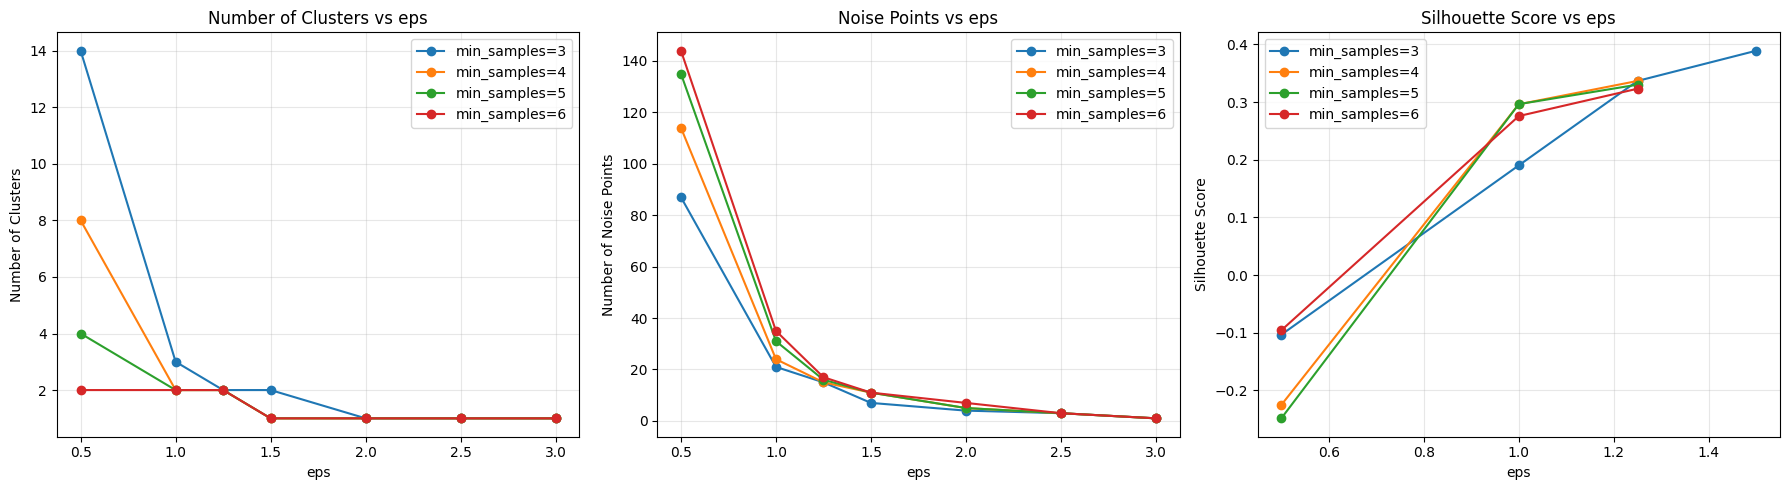

In [128]:
# Plot results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Number of clusters
for min_s in min_samples_list:
    subset = results_df[results_df['min_samples'] == min_s]
    axes[0].plot(subset['eps'], subset['n_clusters'], marker='o', label=f'min_samples={min_s}')
axes[0].set_xlabel('eps')
axes[0].set_ylabel('Number of Clusters')
axes[0].set_title('Number of Clusters vs eps')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Noise points
for min_s in min_samples_list:
    subset = results_df[results_df['min_samples'] == min_s]
    axes[1].plot(subset['eps'], subset['n_noise'], marker='o', label=f'min_samples={min_s}')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('Number of Noise Points')
axes[1].set_title('Noise Points vs eps')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Silhouette score
for min_s in min_samples_list:
    subset = results_df[results_df['min_samples'] == min_s]
    valid = subset[subset['silhouette'] > -1]
    axes[2].plot(valid['eps'], valid['silhouette'], marker='o', label=f'min_samples={min_s}')
axes[2].set_xlabel('eps')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_title('Silhouette Score vs eps')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Number of clusters: 10
Number of noise points: 72

Cluster distribution:
cluster
-1    72
 0     5
 1    11
 2    35
 3     8
 4    11
 5     3
 6     6
 7     4
 8     4
 9     4
Name: count, dtype: int64


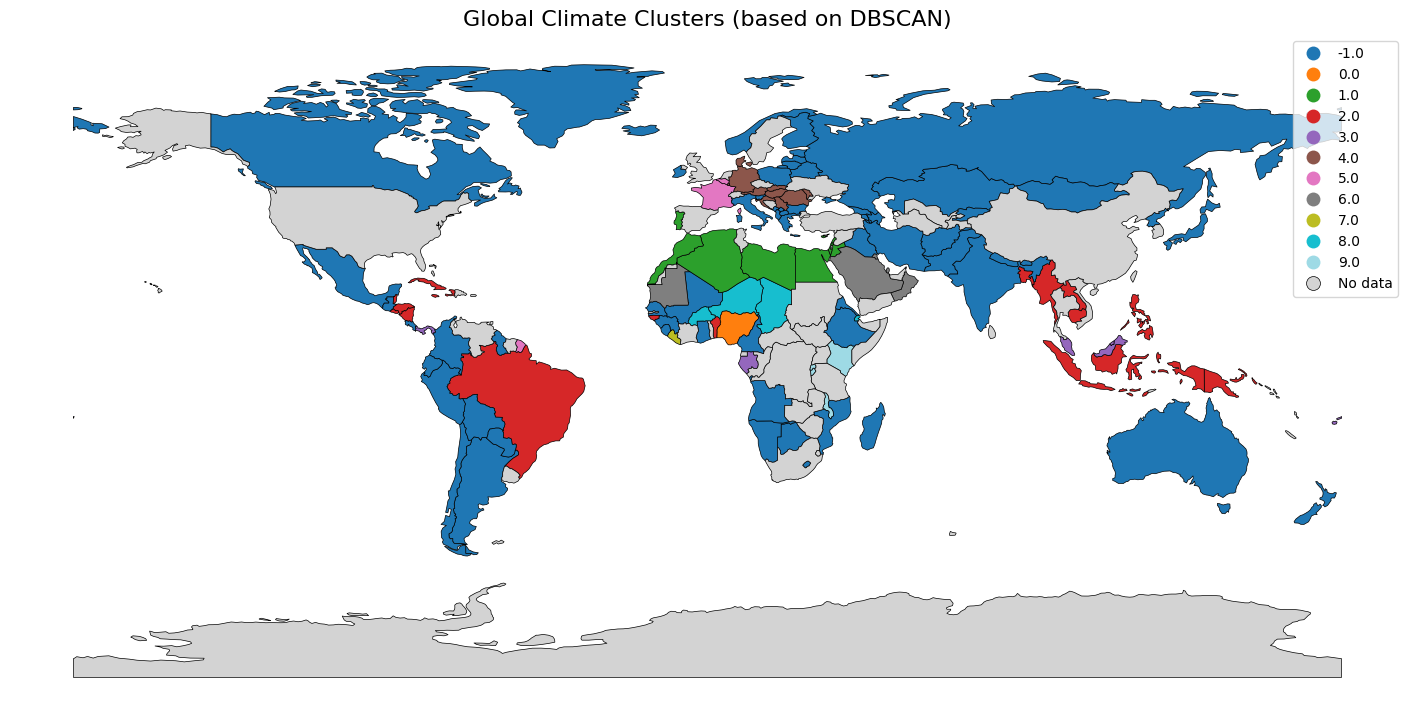

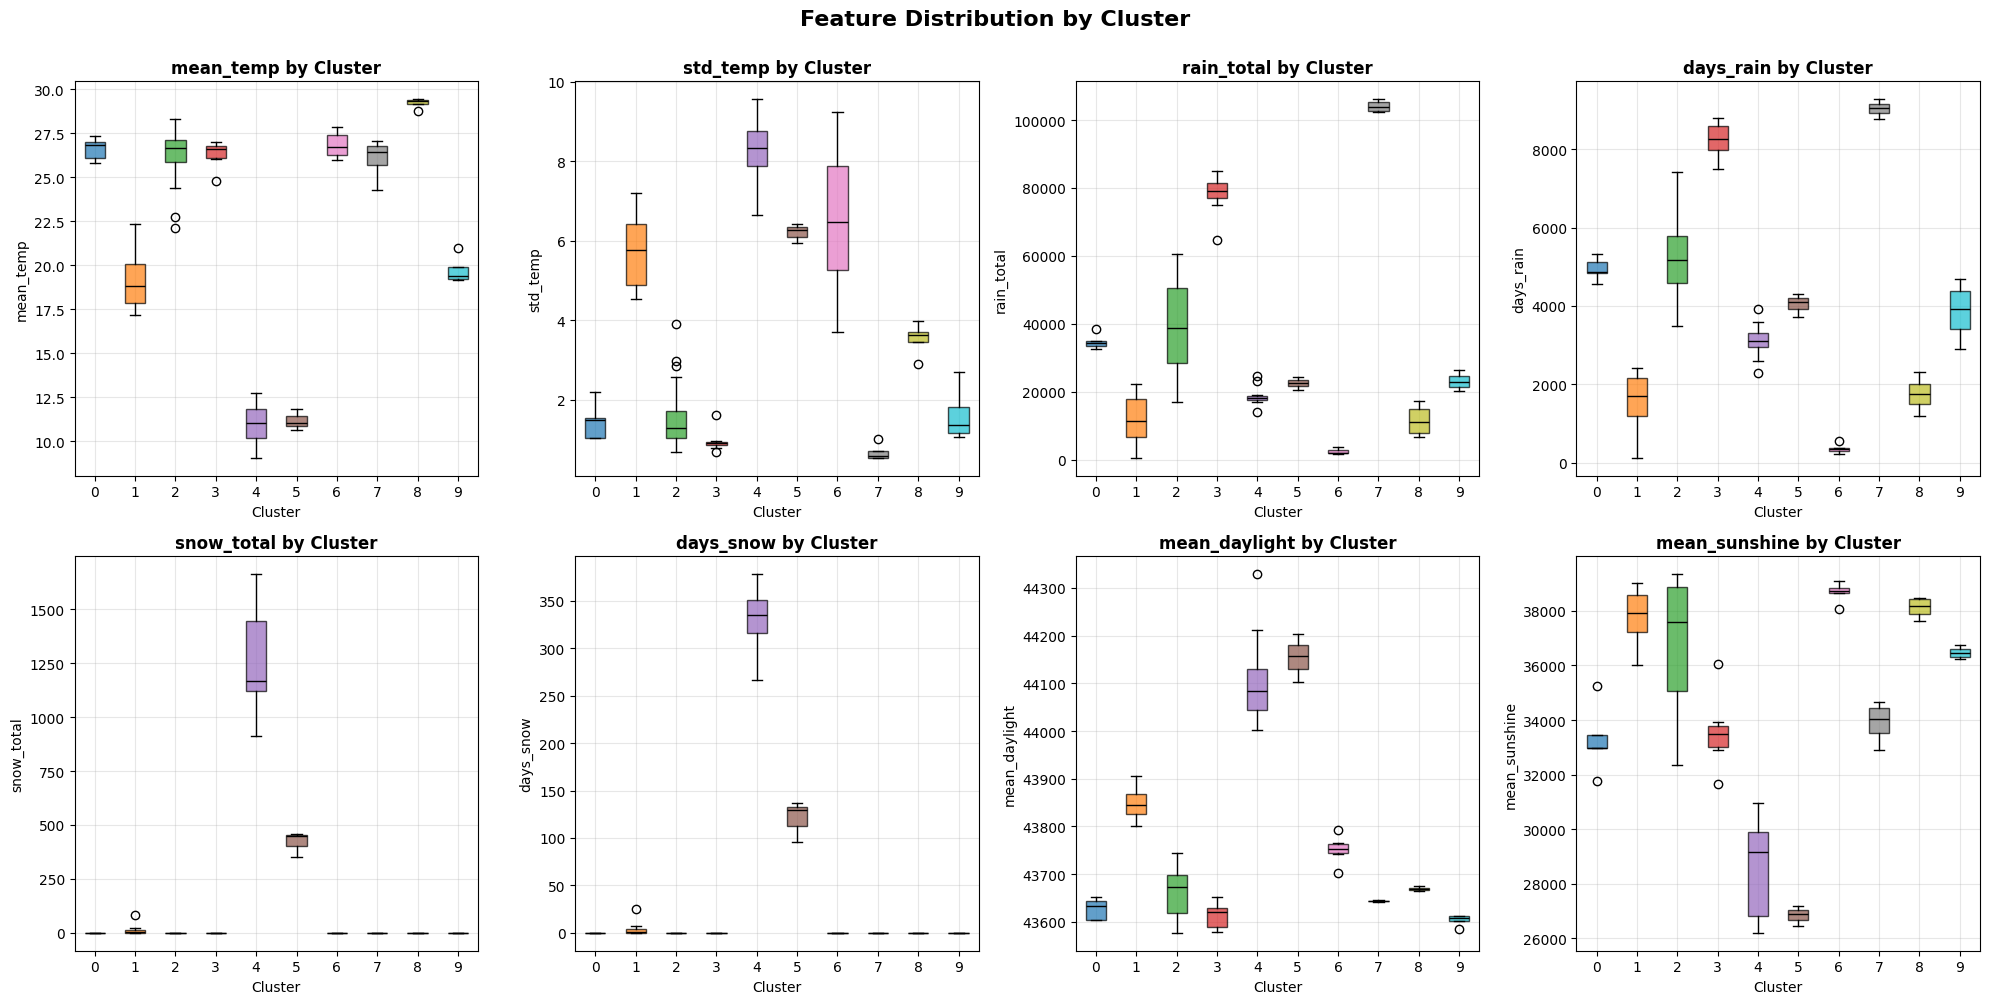

In [154]:
# Choose best parameters (example)
best_eps = 0.6
best_min_samples = 4

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
df_clusters['cluster'] = dbscan.fit_predict(X_scaled)

num_clusters = len(set(df_clusters['cluster'])) - (1 if -1 in df_clusters['cluster'].values else 0)

print(f"Number of clusters: {num_clusters}")
print(f"Number of noise points: {list(df_clusters['cluster']).count(-1)}")
print(f"\nCluster distribution:\n{df_clusters['cluster'].value_counts().sort_index()}")

plot_world(df_clusters, method="DBSCAN")

plot_boxplots(df_clusters, num_clusters)

# Cure clustering

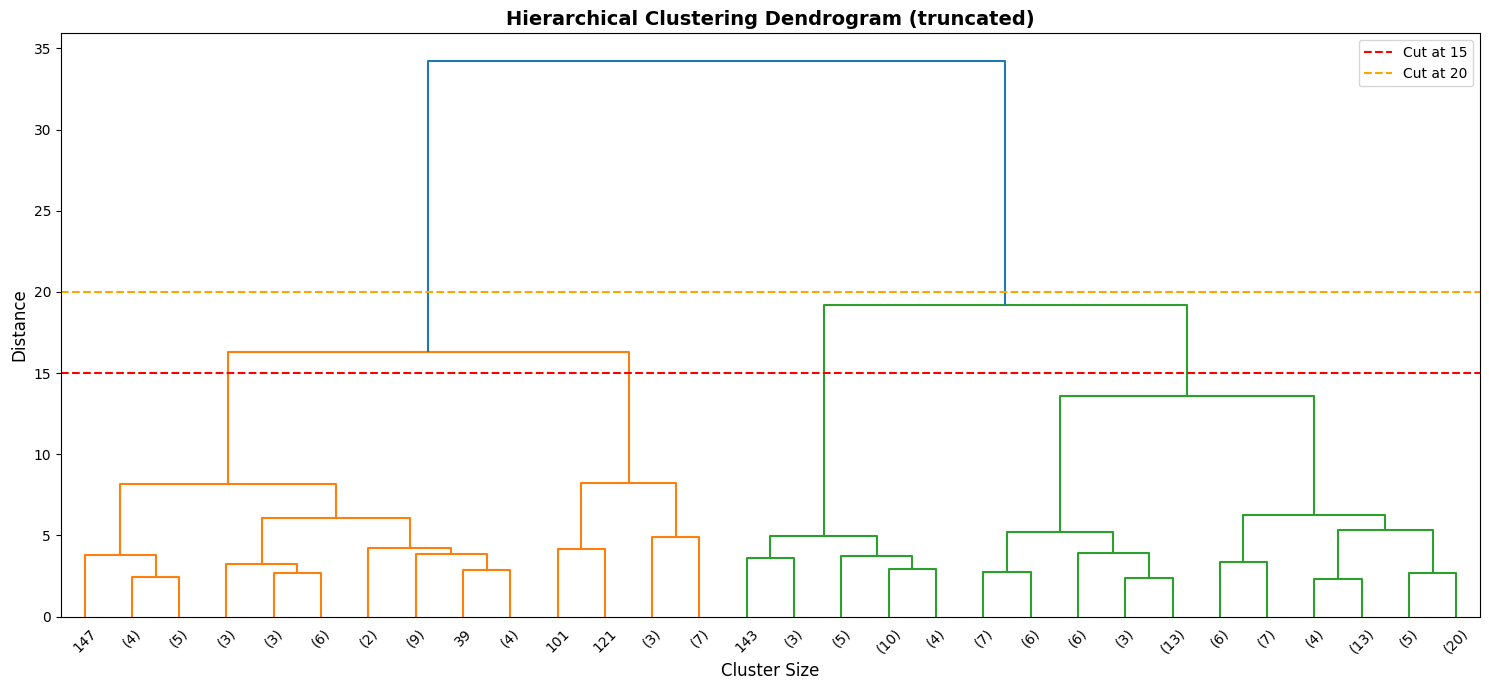

In [175]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Create linkage matrix for dendrogram
linkage_matrix = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(15, 7))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram (truncated)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster Size', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.axhline(y=15, color='r', linestyle='--', label='Cut at 15')
plt.axhline(y=20, color='orange', linestyle='--', label='Cut at 20')
plt.legend()
plt.tight_layout()
plt.show()

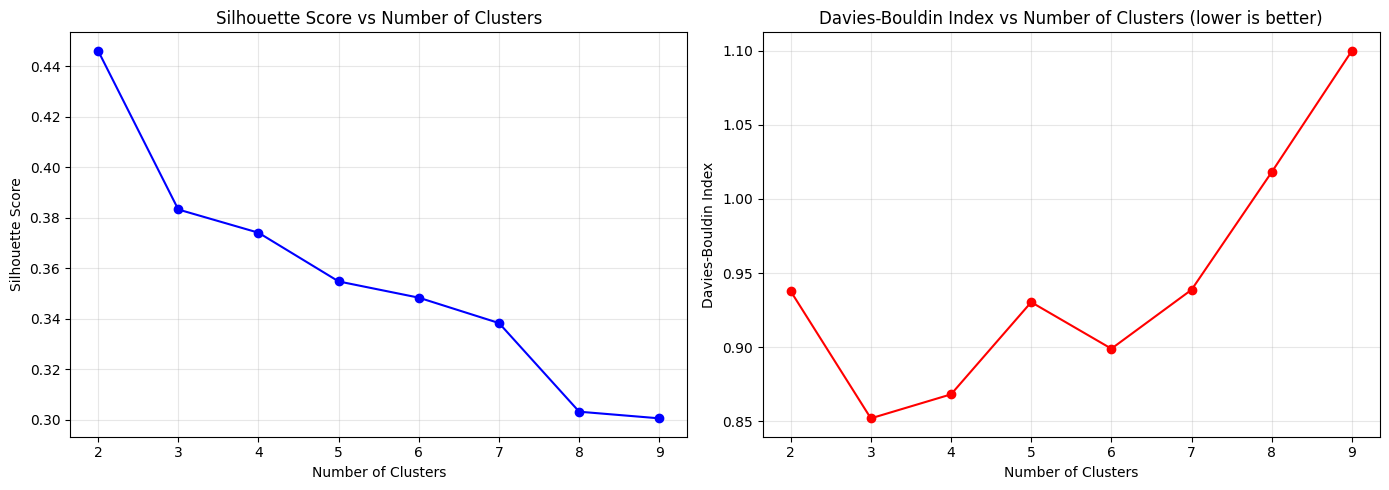

In [177]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Test different number of clusters
sil_scores_agg = []
db_scores = []
k_range = range(2, 10)

for n_clusters in k_range:
    agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = agg.fit_predict(X_scaled)
    
    sil_scores_agg.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

# Plot metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, sil_scores_agg, marker='o', color='blue')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs Number of Clusters')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, db_scores, marker='o', color='red')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('Davies-Bouldin Index vs Number of Clusters (lower is better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [182]:
# Choose best number of clusters
n_clusters_agg = 5

# Apply Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters_agg, linkage='ward')
df_clusters['cluster'] = agg_clustering.fit_predict(X_scaled)

print(f"Number of clusters: {n_clusters_agg}")
print(f"\nCluster distribution:\n{df_clusters['cluster'].value_counts().sort_index()}")

# Compute centroids (manually, since AgglomerativeClustering doesn't provide them)
centroids = df_clusters.groupby('cluster')[features].mean()
print(f"\nCluster centroids:\n{centroids}")

Number of clusters: 5

Cluster distribution:
cluster
0    12
1    38
2    23
3    55
4    35
Name: count, dtype: int64

Cluster centroids:
         mean_temp  std_temp    rain_total    days_rain   snow_total  \
cluster                                                                
0         6.327116  8.871857  21181.441667  3229.833333  4386.684167   
1        11.346568  8.378749  20711.610526  2971.131579  1329.950263   
2        23.210594  1.335662  85668.956522  8008.565217    88.881739   
3        24.069795  1.887408  36769.518182  4787.527273     1.484000   
4        22.881438  5.165392  11424.588571  1503.028571     9.342000   

           days_snow  mean_daylight  mean_sunshine  
cluster                                             
0        1124.500000   44422.116436   25771.537903  
1         331.526316   44051.976135   30731.962231  
2          22.217391   43639.579866   33407.892426  
3           0.327273   43646.878386   36157.950798  
4           2.457143   43742.845976   

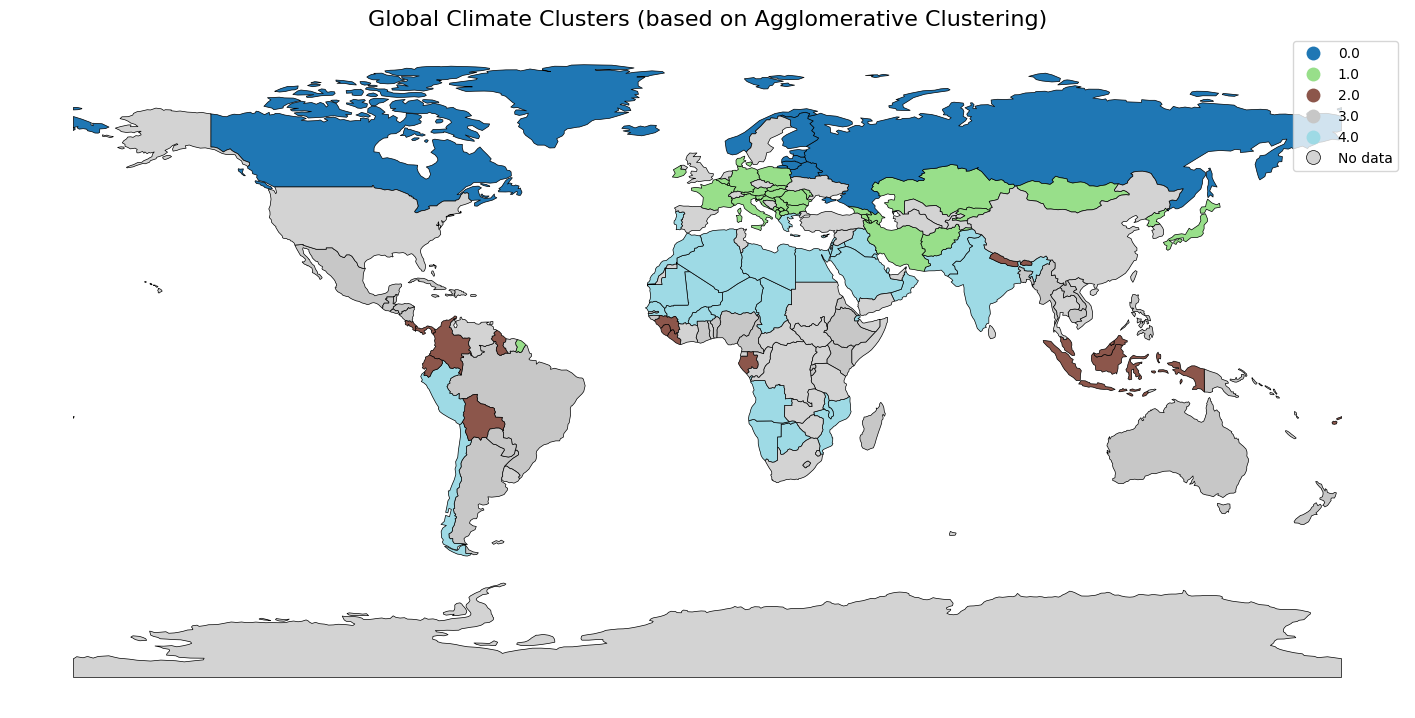

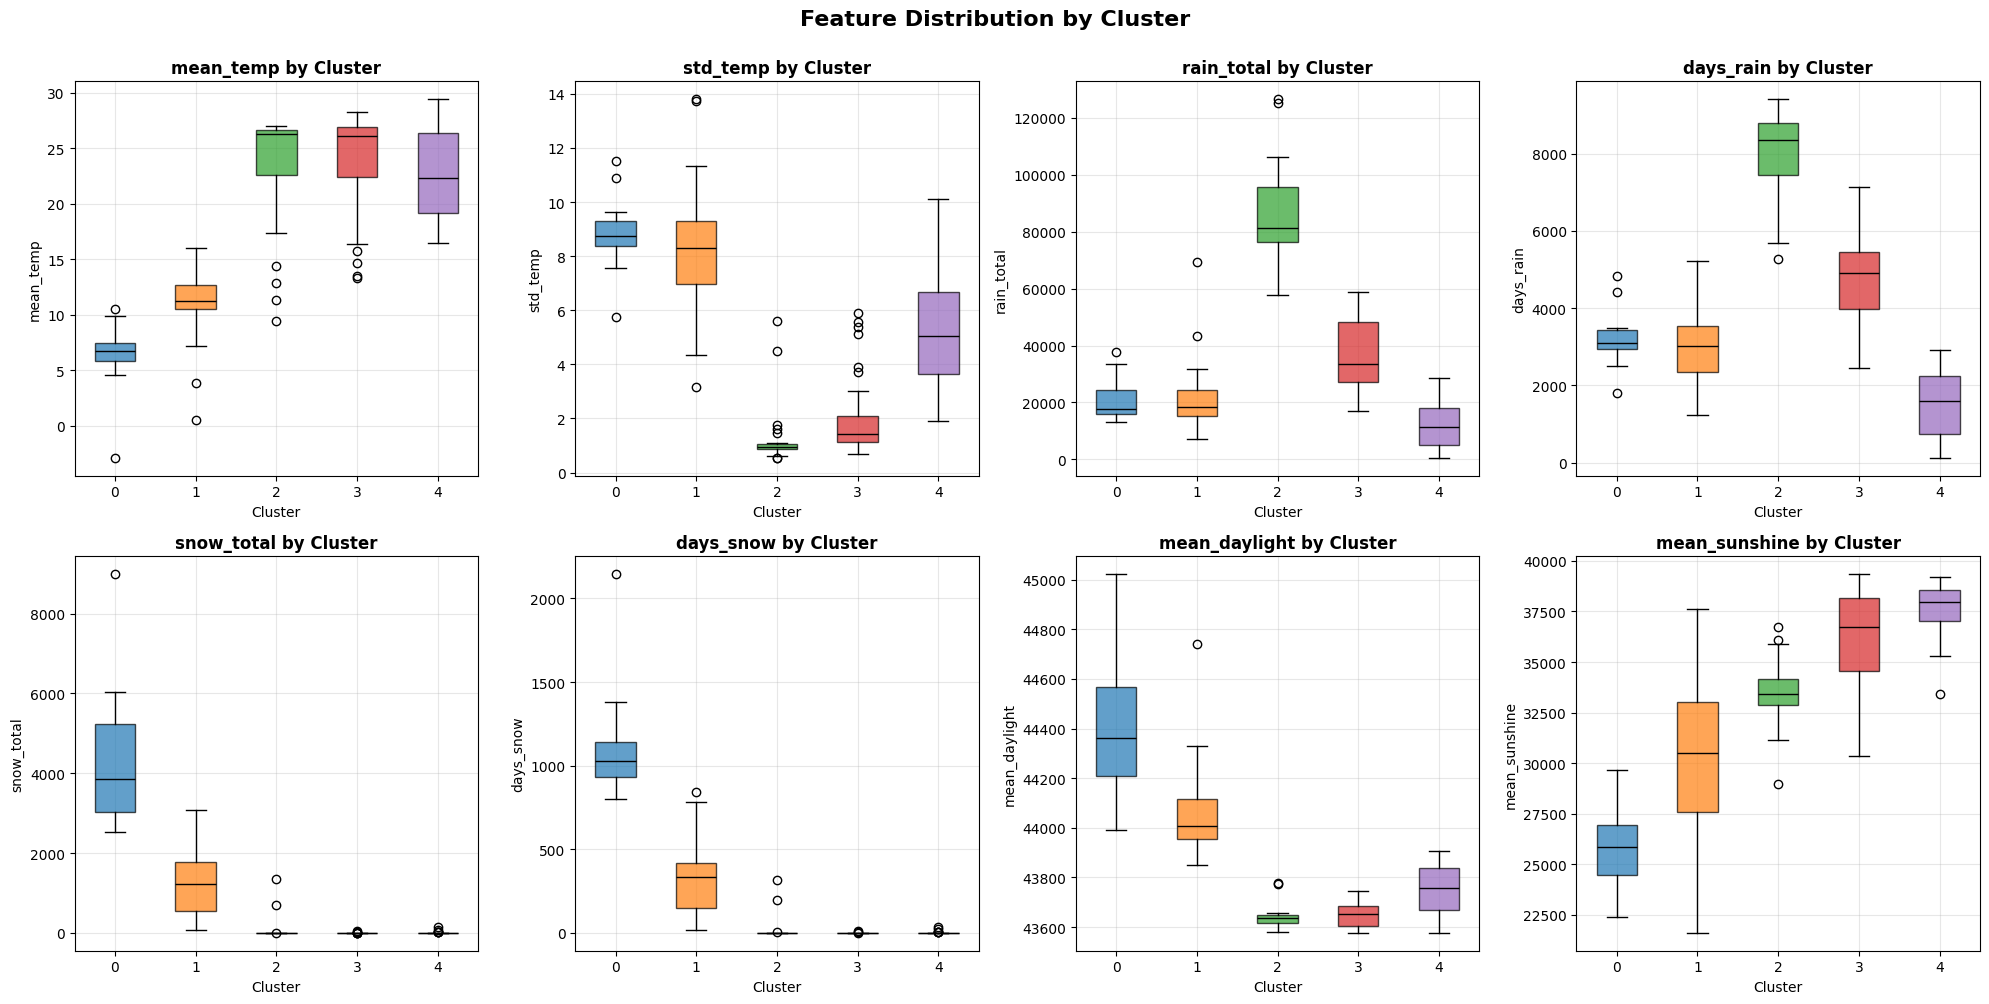

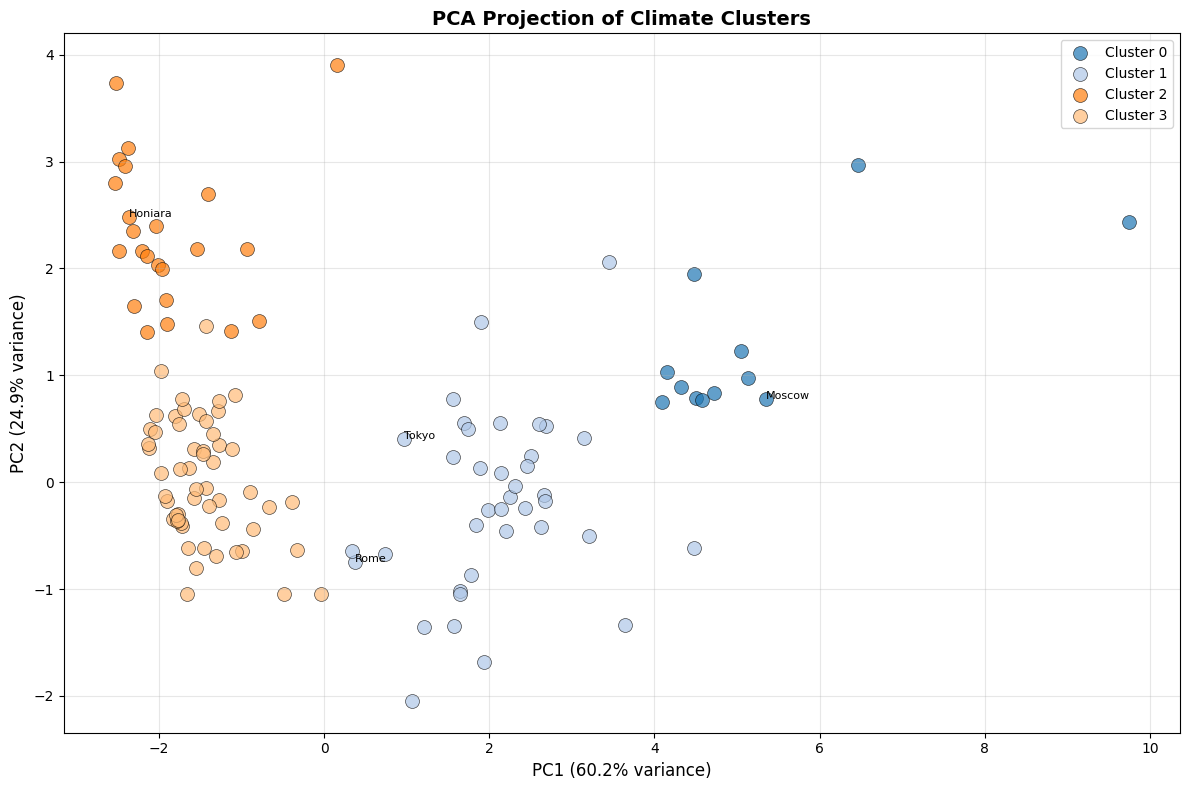

In [184]:
# Plot world map
plot_world(df_clusters, method="Agglomerative Clustering")

# Plot boxplots
plot_boxplots(df_clusters, n_clusters_agg)

plot_PCA(df_clusters)